In [8]:
import numpy as np

input_data = np.load('initial_data/function_4/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.273303, 0.432684, 0.384952, 0.414213],
    [0.360858, 0.334696, 0.389935, 0.443739]
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (30, 4)
After: (32, 4)
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.335

In [9]:
output_data = np.load('initial_data/function_4/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    -1.1816448371847552,
    0.029304207874674137,
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (30,)
After: (32,)
[-2.21082878e+01 -1.46013966e+01 -1.16999325e+01 -1.60537651e+01
 -1.00696334e+01 -1.54870825e+01 -1.26816850e+01 -1.60263998e+01
 -1.70492346e+01 -1.27417660e+01 -2.73163964e+01 -1.35276489e+01
 -1.66791152e+01 -1.65071586e+01 -1.78179993e+01 -2.65618208e+01
 -1.27583242e+01 -1.94415576e+01 -2.89032737e+01 -1.37027469e+01
 -2.94270914e+01 -1.15657420e+01 -2.68577864e+01 -7.96677535e+00
 -6.70208925e+00 -3.26256602e+01 -1.99894979e+01 -4.02554228e+00
 -1.31227823e+01 -2.31394284e+01 -1.18164484e+00  2.93042079e-02]


In [10]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [11]:
# Outputs span extreme ranges, so fit SVR in log|y| space
log_y = np.log(np.abs(output_data))

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(input_data)

print(f"log|y| range: [{log_y.min():.1f}, {log_y.max():.1f}]")
print(f"Negative outputs: {(output_data < 0).sum()} / {len(output_data)}")

log|y| range: [-3.5, 3.5]
Negative outputs: 31 / 32


In [12]:
svr = SVR(kernel='rbf', C=100.0, epsilon=0.5, gamma='scale')
svr.fit(X_scaled, log_y)

log_y_pred = svr.predict(X_scaled)
print(f"In-sample MSE (log space): {mean_squared_error(log_y, log_y_pred):.4f}")
print(f"In-sample R²  (log space): {r2_score(log_y, log_y_pred):.4f}")


In-sample MSE (log space): 0.2017
In-sample R²  (log space): 0.8708


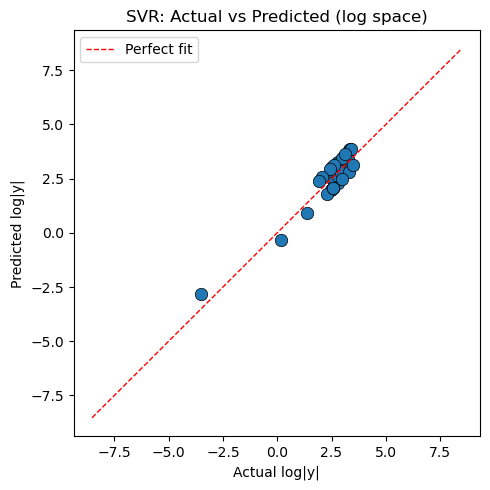

In [13]:
from scipy.stats import norm
plt.figure(figsize=(5, 5))
plt.scatter(log_y, log_y_pred, edgecolors='black', linewidths=0.5, s=80)
lims = [log_y.min() - 5, log_y.max() + 5]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
plt.xlabel('Actual log|y|')
plt.ylabel('Predicted log|y|')
plt.title('SVR: Actual vs Predicted (log space)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
query = np.array([[0.5, 0.5, 0.5, 0.5]])
log_pred = svr.predict(scaler_X.transform(query))[0]

actual_output = -3.985750969810286
actual_log    = np.log(np.abs(actual_output))

pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")    

Query point:           [0.5 0.5 0.5 0.5]
Predicted log|output|: -0.6971
Actual    log|output|: 1.3827
Predicted |output|:    4.9805e-01
Actual    |output|:    -3.9858e+00
Absolute error:        4.4838e+00
Relative error:        112.50%
